
Research's goal : Clustering countries depend on effective level

In [32]:
import os
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
!pwd
!ls /content/drive/MyDrive/Datasets/



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
WHO-COVID-19-global-daily-data.csv


In [33]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/WHO-COVID-19-global-daily-data.csv')
print(df.head())
print(df.dtypes)

print(df.info())

print(df.shape)

  Date_reported Country_code                           Country WHO_region  \
0    2020-01-04           VC  Saint Vincent and the Grenadines        AMR   
1    2020-01-04           SN                           Senegal        AFR   
2    2020-01-04           SB                   Solomon Islands        WPR   
3    2020-01-04           LK                         Sri Lanka       SEAR   
4    2020-01-04           SY              Syrian Arab Republic        EMR   

   New_cases  Cumulative_cases  New_deaths  Cumulative_deaths  
0        NaN                 0         NaN                  0  
1        NaN                 0         NaN                  0  
2        0.0                 0         0.0                  0  
3        0.0                 0         0.0                  0  
4        NaN                 0         NaN                  0  
Date_reported         object
Country_code          object
Country               object
WHO_region            object
New_cases            float64
Cumulati

Date_reported             0
Country_code           2088
Country                   0
WHO_region                0
New_cases            289973
Cumulative_cases          0
New_deaths           346880
Cumulative_deaths         0
dtype: int64


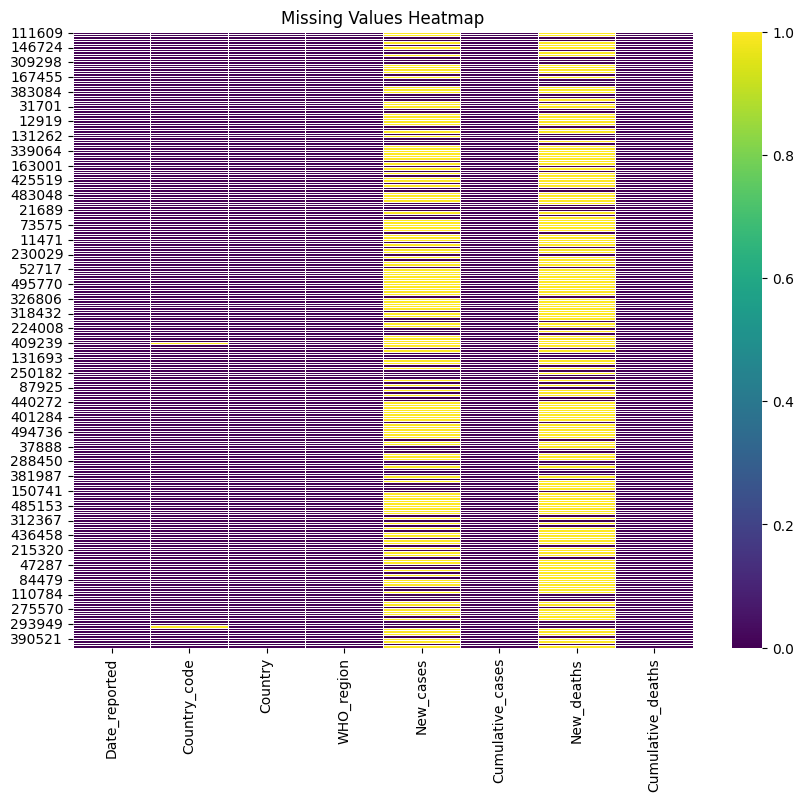

In [34]:
# EDA for missing value
import matplotlib.pyplot as plt
import seaborn as sns


print(df.isnull().sum())

missing_values = df.isnull()
plt.figure(figsize =(10,8))
sns.heatmap(missing_values.sample(250), cmap='viridis', fmt=".2f", linewidths=0.5, cbar = 'false')
plt.title("Missing Values Heatmap")
plt.show()








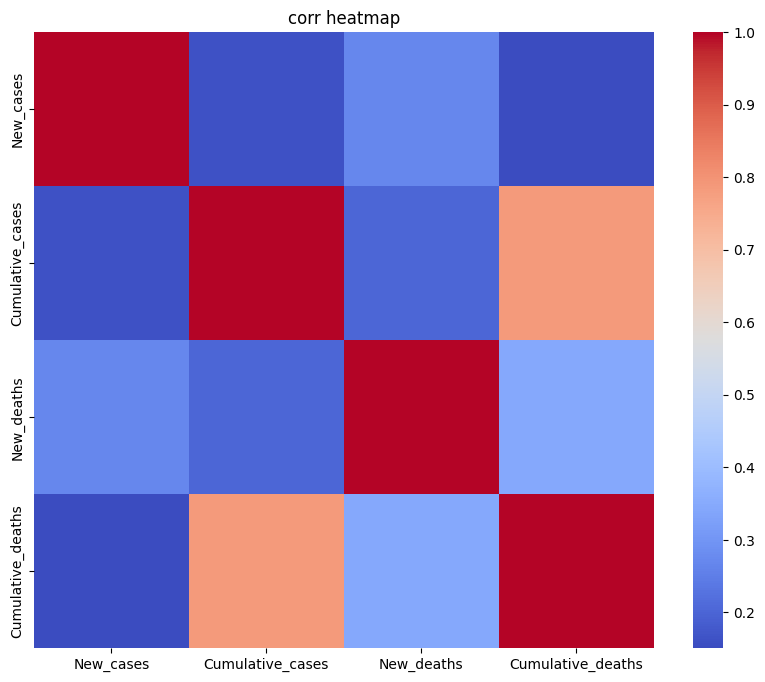

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),cmap="coolwarm",fmt = ".2f")
plt.title("corr heatmap")
plt.show()

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Missing value

df_samples = df.sample(n=1000)
for_KNN = df_samples[['New_deaths','New_cases']]
imputer = KNNImputer(n_neighbors=5, weights = "distance")

new_data = imputer.fit_transform(for_KNN)
df_samples[['New_deaths','New_cases']] = new_data

print(df_samples.isnull().sum())


 # Feature engineering

total_cases = df_samples.groupby('Country')['Cumulative_cases'].max()

total_deaths = df_samples.groupby('Country')['Cumulative_deaths'].max()

new_cases = df_samples.groupby('Country')['New_cases'].sum()

new_deaths = df_samples.groupby('Country')['New_deaths'].sum()

death_rate = (total_deaths / total_cases) * 100




df_cluster = pd.concat([total_cases, total_deaths, new_cases, new_deaths, death_rate], axis=1)
df_cluster.columns = ['total_cases', 'total_deaths', 'new_cases', 'new_deaths', 'death_rate']



for_KNN_2nd = df_cluster[['death_rate']]
imputer2 = KNNImputer(n_neighbors=5, weights = "distance")
death_rate_imputed = imputer2.fit_transform(for_KNN_2nd)

df_cluster['death_rate'] = death_rate_imputed

print(df_cluster.isnull().sum())






scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)






Date_reported        0
Country_code         4
Country              0
WHO_region           0
New_cases            0
Cumulative_cases     0
New_deaths           0
Cumulative_deaths    0
dtype: int64
total_cases     0
total_deaths    0
new_cases       0
new_deaths      0
death_rate      0
dtype: int64


In [60]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 5, random_state=42)
kmeans.fit(df_scaled)

df_cluster['cluster'] = kmeans.labels_
print(df_cluster.head())


                total_cases  total_deaths    new_cases  new_deaths  \
Country                                                              
Afghanistan          235214          7998  1814.179545   44.882093   
Albania              335047          3605  5708.538636  133.264615   
Algeria              272154          6881  1645.179545   40.421538   
American Samoa         8359            34  1633.179545   40.421538   
Andorra               48015           159  3292.359091   83.843077   

                death_rate  cluster  
Country                              
Afghanistan       3.400308        0  
Albania           1.075968        4  
Algeria           2.528348        0  
American Samoa    0.406747        4  
Andorra           0.331147        4  
